In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
ls drive/MyDrive/ai_2024/class_projects/scripts_excercise

copying_materials.py  EDA_Finance.py  get_materials.py  nasa_temperature.py  __pycache__/


In [ ]:
"drive/MyDrive/ai_2024/class_projects/scripts_excercise"

In [ ]:
%%writefile drive/MyDrive/ai_2024/class_projects/scripts_excercise/print_today.py

from datetime import datetime, timedelta
def print_today():
    """
    print today's date and time in yyyy_mm_DD HH:MM format
    """
    # use lib to get today's value
    today = datetime.today()
    today = today + timedelta(hours=-8)
    today_str = today.strftime("%Y_%m_%D %H:%M")
    print(f"Today is {today_str}")



Overwriting drive/MyDrive/ai_2024/class_projects/scripts_excercise/print_today.py


In [ ]:
today = datetime.today()
today = today + timedelta(hours=-8)
today_str = today.strftime("%Y_%m_%D %H:%M")
print(f"Today is {today_str}")

Today is 2024_06_06/20/24 09:45


In [ ]:
import sys
sys.path.append("drive/MyDrive/ai_2024/class_projects/scripts_excercise")

In [ ]:
import print_today as pt

In [ ]:
pt.print_today()

Today is 2024_06_06/20/24 17:45


In [ ]:
print_today()

Today is 2024_06_06/20/24 17:36


# Class 2401 - Project PIA

<font size=6 color=green>Python In Action with AI and Stock Trading</font><br>
<font size=7 color=blue>Data Analysis for the project</font>

# Problem Statement

**Exploratory Data Analysis on Stock Data**

### **Objectives:**
* Use the yfinance library to fetch stock data
* Learn the essentials of Pandas for data manipulation and analysis
* Read and manipulate stock data using Pandas
* Perform basic data analysis on stock data
* Visualize stock data using Python libraries


<font size=6 color=red> Before we start, choose 50 stocks from the list</font>

* Nasdaq file: /content/drive/MyDrive/ai_2024/class_projects/pia_aitrade/data/NASDAQ_ticker_info.csv
* NYSE file: /content/drive/MyDrive/ai_2024/class_projects/pia_aitrade/data/NYSE_ticker_info.csv

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

In [ ]:
tickers_nasdaq = "/content/drive/MyDrive/Classroom/AI2024/PIA_2Proj_2024/ClassPIA202402/data/Project_AIInStock/NASDAQ_ticker_info.csv"
tickers_nyse = "/content/drive/MyDrive/Classroom/AI2024/PIA_2Proj_2024/ClassPIA202402/data/Project_AIInStock/NYSE_ticker_info.csv"
df_nasdaq = pd.read_csv(tickers_nasdaq)
df_nyse = pd.read_csv(tickers_nyse)

In [ ]:
df_nyse.shape, df_nyse.head(4)

((1489, 6),
   Ticker                        industry       sector  averageVolume  \
 0    DDD               Computer Hardware   Technology        1233847   
 1    MMM                   Conglomerates  Industrials        3585593   
 2   EGHT            Software—Application   Technology        1684647   
 3    AOS  Specialty Industrial Machinery  Industrials        1041559   
 
    averageVolume10days    marketCap  
 0              1437880   1299746048  
 1              3873250  55796105216  
 2              1735390    512001600  
 3               740390  10887487488  )

In [ ]:
df_nasdaq.shape, df_nasdaq.tail(4)

((3531, 6),
      Ticker                industry              sector  averageVolume  \
 3527   AREB  Footwear & Accessories   Consumer Cyclical         192899   
 3528   GNLN                 Tobacco  Consumer Defensive          73740   
 3529   MCOM   Recreational Vehicles   Consumer Cyclical        6500129   
 3530   BDRX           Biotechnology          Healthcare        5179942   
 
       averageVolume10days  marketCap  
 3527               970841    1713366  
 3528               253420    1615303  
 3529             13515520    4702409  
 3530             10496450    1239646  )

### How to choose?

* e.g., I want to choose top 50 companines in "Technology" sector by market cap


In [ ]:
# 1. Filter
df = df_nasdaq[df_nasdaq["sector"]=="Technology"]
#df.sort_values(by="marketCap", ascending=False, inplace=True)
#df.head(2)
df.head(2)

,Ticker,industry,sector,averageVolume,averageVolume10days,marketCap
0,AAPL,Consumer Electronics,Technology,56888032,51655080,3027145850880
1,MSFT,Software—Infrastructure,Technology,27240886,22059840,2513121050624


In [ ]:
threshold = 50000000000.22333
df = df_nasdaq[df_nasdaq["marketCap"]>threshold]
df.sort_values(by = "Ticker", ascending=True, inplace=True)
df.tail(5)

<ipython-input-17-e18076294d43>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values(by = "Ticker", ascending=True, inplace=True)


,Ticker,industry,sector,averageVolume,averageVolume10days,marketCap
17,TMUS,Telecom Services,Communication Services,6525555,4527550,167180681216
5,TSLA,Auto Manufacturers,Consumer Cyclical,138546314,158883480,886889512960
18,TXN,Semiconductors,Technology,4914739,4599910,163159883776
34,VRTX,Biotechnology,Healthcare,1241634,1218810,89517350912
52,WDAY,Software—Application,Technology,2081768,1855550,58617987072


In [ ]:
# 2. get the tickers
TICKER_LIST = df["Ticker"][0:50].to_list()
len(TICKER_LIST), TICKER_LIST
print()

# 1.Libraries

In [ ]:
!pip install yfinance seaborn --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

import seaborn as sns

# style
sns.set_style('whitegrid')
plt.style.use("fivethirtyeight")
%matplotlib inline

# 2.Prepare data



* stock historical data come in several granularities.
* for this project, let take past 1 year of data for every ticker
* we will save the raw data after i pull it from yfinance

## 2.1. Pull data -- Inspection

* we could pull data one by one.
* problems is that it will be too many requests
* so let's pull all our 50 at once

**Something new about dataframe**

In [ ]:

TICKER = "AAPL GOOG"
end_date = datetime.today()
start_date = end_date - timedelta(days=1*365)

# Download the stock data
df_stock_history = yf.download(TICKER, start=start_date, end=end_date, group_by='ticker')
df_stock_history.head(3)


[*********************100%%**********************]  2 of 2 completed


Ticker            GOOG                                                  \
Price             Open        High         Low       Close   Adj Close   
Date                                                                     
2023-08-09  132.190002  132.470001  129.505005  130.149994  130.002060   
2023-08-10  131.970001  132.647003  130.035004  130.210007  130.061996   
2023-08-11  129.201996  130.440002  128.750000  130.169998  130.022034   

Ticker                      AAPL                                      \
Price         Volume        Open        High         Low       Close   
Date                                                                   
2023-08-09  17745200  180.869995  180.929993  177.009995  178.190002   
2023-08-10  17855700  179.479996  180.750000  177.600006  177.970001   
2023-08-11  15191500  177.320007  178.619995  176.550003  177.789993   

Ticker                            
Price        Adj Close    Volume  
Date                              
2023-08-09  177.248672  60378500  
2023-08-10  177.029861  54686900  
2023-08-11  177.089615  51988100

In [ ]:
data = df_stock_history.copy()
data = data.stack(level=0).rename_axis(['Date', 'Ticker']).reset_index()

data.index = data.index.set_names('Seq')

In [ ]:
data.shape

(502, 8)

## 2.2. Pull data -- pull TICKERS' data

In [ ]:
# let's build a function
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta
import os

def download_stock_data(tickers, filename, refresh=False):
    """ docstring
    Downloads stock data for the given tickers and saves to a file.

    Parameters:
    - tickers: str, comma-separated list of ticker symbols
    - filename: str, the filename to save the data
    - refresh: bool, whether to refresh the data if the file exists
    """
    if not refresh and os.path.exists(filename):
        print(f"File '{filename}' already exists. Skipping download.")
        return pd.read_csv(filename)

    end_date = datetime.today()
    start_date = end_date - timedelta(days=1*365)

    # Download the stock data
    df_stock_history = yf.download(tickers, start=start_date, end=end_date, group_by='ticker')

    # Reset the index to have 'Date' as a column
    df_stock_history = df_stock_history.stack(level=0).rename_axis(['Date', 'Ticker']).reset_index(level=1)

    # Rename the default integer index to "Seq"
    df_stock_history.index = df_stock_history.index.set_names('Seq')

    # Save to file
    df_stock_history.to_csv(filename, index=False)
    print(f"Data downloaded and saved to '{filename}'.")

    return df_stock_history

**run it**

In [ ]:
# run it
import copy

tickers = copy.deepcopy(TICKER_LIST)

filename = "/content/drive/MyDrive/Classroom/AI2024/PIA_2Proj_2024/ClassPIA202402/data/Project_AIInStock/stock_data_full.csv"
project_stock_data = download_stock_data(tickers = TICKER_LIST, filename = filename, refresh = True)
# Display the first few rows of the dataframe
project_stock_data.head(2)

[*********************100%%**********************]  50 of 50 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['ATVI']: YFTzMissingError('$%ticker%: possibly delisted; No timezone found')


Data downloaded and saved to '/content/drive/MyDrive/Classroom/AI2024/PIA_2Proj_2024/ClassPIA202402/data/Project_AIInStock/stock_data_full.csv'.


Price,Ticker,Open,High,Low,Close,Adj Close,Volume
Seq,,,,,,,
2023-08-09,AAPL,180.869995,180.929993,177.009995,178.190002,177.248672,60378500.0
2023-08-09,ABNB,140.139999,140.550003,137.330002,137.869995,137.869995,3389700.0


In [ ]:
[c for c in TICKER_LIST if c   not in list(project_stock_data["Ticker"].unique())]

['ATVI']

## 2.3. Inspect (brief)
* we did it already before

In [ ]:
 # First take a copy!!!!
 DATA = project_stock_data.copy()

In [ ]:
DATA.describe()

Price,Open,High,Low,Close,Adj Close,Volume
count,12299.000000,12299.000000,12299.000000,12299.000000,12299.000000,1.229900e+04
mean,356.275029,360.176484,352.266119,356.216676,354.923879,2.005696e+07
std,542.706850,548.290371,536.998477,542.607675,541.227503,6.928804e+07
min,19.950001,20.250000,18.950001,18.990000,18.990000,7.940000e+04
25%,76.785000,77.410004,76.005001,76.709999,75.661442,1.521400e+06
50%,186.990005,188.429993,184.979996,186.520004,185.410004,4.099700e+06
75%,407.974991,412.025009,403.790009,407.205002,406.821213,1.407665e+07
max,4117.000000,4144.319824,4110.640137,4119.089844,4119.089844,1.156044e+09


In [ ]:
DATA.nunique()

,0
Price,
Ticker,49
Open,10612
High,10827
Low,10785
Close,10879
Adj Close,11810
Volume,11731


**which ticker doesn't have data**

In [ ]:
tickers_have_data = DATA["Ticker"].unique()
tickers_have_data

array(['AAPL', 'ADBE', 'ADI', 'ADSK', 'AMAT', 'AMD', 'ANSS', 'ASML',
       'AVGO', 'BSY', 'CDNS', 'CDW', 'CRWD', 'CSCO', 'CTSH', 'DDOG',
       'ENPH', 'ENTG', 'ERIC', 'FSLR', 'FTNT', 'GFS', 'INTC', 'INTU',
       'KLAC', 'LRCX', 'MCHP', 'MDB', 'MPWR', 'MRVL', 'MSFT', 'MU',
       'NTAP', 'NVDA', 'NXPI', 'ON', 'PANW', 'PTC', 'QCOM', 'SNPS',
       'SWKS', 'TEAM', 'TER', 'TTD', 'TXN', 'VRSN', 'WDAY', 'ZM', 'ZS'],
      dtype=object)

In [ ]:
[t for t in TICKER_LIST if t not in tickers_have_data]

['SPLK']

In [ ]:
DATA.count()

Price
Ticker       12250
Adj Close    12250
Close        12250
High         12250
Low          12250
Open         12250
Volume       12250
dtype: int64

## 2.4. Visualize

* Visualize all tickers

In [ ]:
tickers_have_data = DATA["Ticker"].unique()
tickers_have_data

array(['AAPL', 'ABNB', 'ADBE', 'ADI', 'ADP', 'AMAT', 'AMD', 'AMGN',
       'AMZN', 'ASML', 'AVGO', 'AZN', 'BIDU', 'BKNG', 'CDNS', 'CHTR',
       'CMCSA', 'CME', 'COST', 'CSCO', 'CSX', 'EQIX', 'FTNT', 'GILD',
       'GOOGL', 'HON', 'INTC', 'INTU', 'ISRG', 'JD', 'KLAC', 'LRCX',
       'MAR', 'MDLZ', 'MELI', 'META', 'MNST', 'MRVL', 'MSFT', 'MU',
       'NFLX', 'NTES', 'NVDA', 'NXPI', 'ORLY', 'PANW', 'PDD', 'PEP',
       'PYPL'], dtype=object)

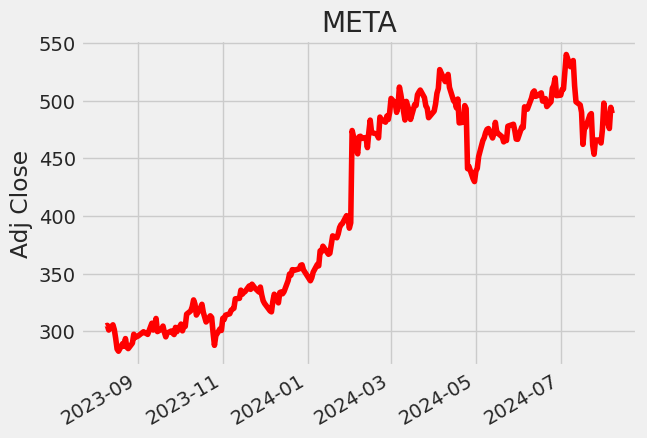

In [ ]:
# plot one:
DATA[DATA["Ticker"]=="META"]['Adj Close'].plot(color='r')
plt.ylabel('Adj Close')
plt.xlabel(None)
plt.title("META")
plt.show()

In [ ]:
# let list all with data
# lets make a function

import pandas as pd
import matplotlib.pyplot as plt
import math

def plot_tickers_price(df, price_type, output_fig_filename):
    """
    Plots the price data for multiple tickers and saves the figure to a file.

    Parameters:
    - df: pd.DataFrame
        DataFrame containing the stock data with 'Ticker' and specified price type columns.
    - price_type: str
        The type of price to plot (e.g., 'Adj Close', 'Close').
    - output_fig_filename: str
        The filename to save the plot.

    Returns:
    - None
    """
    # Extract unique tickers from the DataFrame
    tickers = df['Ticker'].unique()

    # Calculate the number of tickers and adjust figure height
    num_tickers = len(tickers)
    fig_height = 4 * math.ceil(num_tickers / 2)  # Adjust height according to the number of tickers

    # Create a figure with adjusted size
    plt.figure(figsize=(20, fig_height))
    plt.subplots_adjust(top=1.25, bottom=1.2)

    # Loop through each ticker and create a subplot
    for i, ticker in enumerate(tickers, 1):
        plt.subplot(math.ceil(num_tickers / 2), 2, i)
        df[df["Ticker"] == ticker][price_type].plot(color='r')
        plt.ylabel(price_type)
        plt.xlabel(None)
        plt.title(ticker)

    # Adjust layout and save the figure to a file
    plt.tight_layout()
    plt.savefig(output_fig_filename)
    plt.show()


In [ ]:
# Example usage
# Assuming df_stock_history is your DataFrame
price_type = 'Adj Close'
filename = f"/content/drive/MyDrive/Classroom/AI2024/PIA_2Proj_2024/ClassPIA202402/data/Project_AIInStock/stock_plots_{price_type}.png"
data = DATA.copy()
plot_tickers_price(df = data, price_type = price_type, output_fig_filename = filename)

In [ ]:
# Example usage
# Assuming df_stock_history is your DataFrame
price_type = 'Volume'
filename = f"/content/drive/MyDrive/ai_2024/class_projects/pia_aitrade/data/stock_plots_{price_type}.png"
data = DATA.copy()
plot_tickers_price(df = data, price_type = price_type, output_fig_filename = filename)

# 3.Moving average for data
* As in the, we are doing moving average
* lets do moving average for 10, 20 and 50 days
* use Adj Close price

## 3.1.calculating rolling average

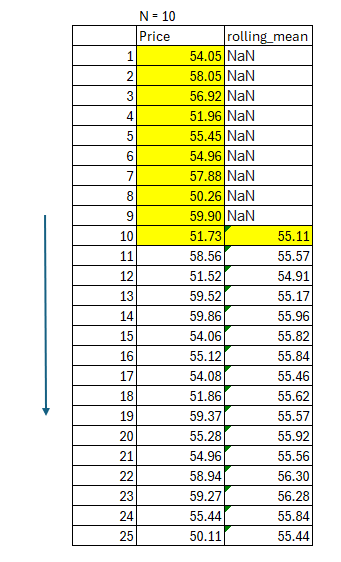

In [ ]:
from IPython.display import Image
Image('https://raw.githubusercontent.com/stempro/genaisp/genaisp/data/mv.png', height=400)

* The simple moving average = (sum of the an asset price over the past n periods) / (number of periods)

${SMA}_{N+m} = \frac{price_{m} + price_{m+1} + ... + price_{m+N}}{N}$



In [ ]:
# we will take one ticker to explain
one_stock = DATA[DATA["Ticker"]=="AAPL"]
one_stock.head(2)

Price,Ticker,Open,High,Low,Close,Adj Close,Volume
Seq,,,,,,,
2023-08-09,AAPL,180.869995,180.929993,177.009995,178.190002,177.248672,60378500.0
2023-08-10,AAPL,179.479996,180.750000,177.600006,177.970001,177.029861,54686900.0


In [ ]:
one_stock['Adj Close'].rolling(20).mean()

,Adj Close
Seq,
2023-08-09,NaN
2023-08-10,NaN
2023-08-11,NaN
2023-08-14,NaN
2023-08-15,NaN
...,...
2024-08-01,225.048000
2024-08-02,224.724001
2024-08-05,223.796500


## 3.2 calculate and populate moving average by 10, 20, 50 days

In [ ]:
f = {}
f["a"] = 333
f

{'a': 333}

In [ ]:
###
ma_day = [10, 20, 50]

import pandas as pd

def calculate_moving_averages(df_data, ma_days = ma_day):
    """
    Calculate moving averages for specified days for each company in the DataFrame.

    Parameters:
    - df_data: pd.DataFrame
        DataFrame containing the stock data with 'Ticker' and 'Adj Close' columns.
    - ma_days: list of int
        List of integers representing the moving average days.

    Returns:
    - pd.DataFrame
        DataFrame with added moving average columns for each company.
    """
    # Iterate over each moving average day
    for ma in ma_days:
        column_name = f"MA for {ma} days"
        # Calculate the moving average for each company
        df_data[column_name] = df_data.groupby('Ticker')['Adj Close'].transform(lambda x: x.rolling(ma).mean())

    return df_data



In [ ]:
df_data = DATA.copy()

ma_days = [10, 20, 50]
df_with_ma = calculate_moving_averages(df_data = df_data, ma_days = ma_days)

df_with_ma


Price,Ticker,Open,High,Low,Close,Adj Close,Volume,MA for 10 days,MA for 20 days,MA for 50 days
Seq,,,,,,,,,,
2023-08-09,AAPL,180.869995,180.929993,177.009995,178.190002,177.248672,60378500.0,NaN,NaN,NaN
2023-08-09,ABNB,140.139999,140.550003,137.330002,137.869995,137.869995,3389700.0,NaN,NaN,NaN
2023-08-09,ADBE,520.549988,520.969971,509.529999,513.780029,513.780029,1843800.0,NaN,NaN,NaN
2023-08-09,ADI,186.410004,187.500000,184.389999,184.809998,181.492508,2341900.0,NaN,NaN,NaN
2023-08-09,ADP,248.800003,251.300003,248.309998,250.309998,244.730423,1145000.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2024-08-07,ORLY,1109.010010,1131.675049,1106.969971,1109.050049,1109.050049,361749.0,1118.494019,1080.768506,1040.806205
2024-08-07,PANW,311.149994,314.779999,304.170013,304.209991,304.209991,3464874.0,313.278000,323.007002,320.153001
2024-08-07,PDD,134.880005,136.169998,132.660004,133.149994,133.149994,5062991.0,128.737000,131.949501,138.551400


## 3.3 Put together visualize and fig to a module

In [ ]:
# %%writefile /content/drive/MyDrive/Classroom/AI2024/PIA_2Proj_2024/ClassPIA202402/scripts/visualize_savefig.py

# let list all with data
# lets make a function

import pandas as pd
import matplotlib.pyplot as plt
import math

def plot_tickers_price(df_with_ma, price_type, output_fig_filename):
    """
    Plots the price data for multiple tickers and saves the figure to a file.

    Parameters:
    - df_with_ma: pd.DataFrame
        DataFrame containing the stock data with 'Ticker' and specified price type columns.
    - price_type: str
        The type of price to plot (e.g., 'Adj Close', 'Close').
    - output_fig_filename: str
        The filename to save the plot.

    Returns:
    - None
    """
    # Extract unique tickers from the DataFrame
    tickers = df_with_ma['Ticker'].unique()

    # Calculate the number of tickers and adjust figure height
    num_tickers = len(tickers)
    fig_height = 4 * math.ceil(num_tickers / 2)  # Adjust height according to the number of tickers

    # Create a figure with adjusted size
    plt.figure(figsize=(20, fig_height))
    plt.subplots_adjust(top=1.25, bottom=1.2)

    # Loop through each ticker and create a subplot
    for i, ticker in enumerate(tickers, 1):
        plt.subplot(math.ceil(num_tickers / 2), 2, i)
        df_with_ma[df_with_ma["Ticker"] == ticker][price_type].plot(color='r')
        plt.ylabel(price_type)
        plt.xlabel(None)
        plt.title(ticker)

    # Adjust layout and save the figure to a file
    plt.tight_layout()
    plt.savefig(output_fig_filename)
    plt.show()


def plot_all_ticker_moving_averages(df_with_ma,  output_filename, ma_days = [10, 20, 50]):
    """
    Plots the Adjusted Close price and moving average prices for all tickers in the DataFrame and saves the plot to a file.

    Parameters:
    - df_with_ma: pd.DataFrame, DataFrame containing the stock data with 'Ticker' and 'Adj Close' columns
    - ma_days: list of int, list of integers representing the moving average days
    - output_filename: str, filename to save the combined plot

    Returns:
    - None
    """
    # Calculate moving averages

    # Get the list of tickers
    tickers = df_with_ma['Ticker'].unique()
    num_tickers = len(tickers)

    # Determine the number of rows and columns for the subplots
    num_cols = 2
    num_rows = math.ceil(num_tickers / num_cols)

    # Create the figure
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 5 * num_rows))
    axes = axes.flatten()  # Flatten the axes array for easy iteration

    # Plot Adjusted Close and Moving Averages for each ticker
    for i, ticker in enumerate(tickers):
        df_ticker = df_with_ma[df_with_ma['Ticker'] == ticker]
        ax = axes[i]
        ax.plot(  df_ticker['Adj Close'], label='Adj Close', color='blue')

        for ma in ma_days:
            column_name = f"MA for {ma} days"
            ax.plot( df_ticker[column_name], label=column_name)

        ax.set_title(f"{ticker} - Adjusted Close and Moving Averages")
        ax.set_xlabel('Date')
        ax.set_ylabel('Price')
        ax.legend()
        ax.grid(True)

    # Adjust layout and remove empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.savefig(output_filename)
    plt.show()


In [ ]:
# run it

ma_days = [10, 20, 50]
output_filename = '/content/drive/MyDrive/Classroom/AI2024/PIA_2Proj_2024/ClassPIA202402/data/Project_AIInStock/all_tickers_moving_averages.png'  # File to save the combined plot
plot_all_ticker_moving_averages(df_with_ma = df_with_ma, ma_days = ma_days, output_filename = output_filename)



## 3.3.Put together visualize and fig to a module

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import math

def plot_all_ticker_moving_averages(df_data, ma_days, output_filename):
    """
    Plots the Adjusted Close price and moving average prices for all tickers in the DataFrame and saves the plot to a file.

    Parameters:
    - df_data: pd.DataFrame, DataFrame containing the stock data with 'Ticker' and 'Adj Close' columns
    - ma_days: list of int, list of integers representing the moving average days
    - output_filename: str, filename to save the combined plot

    Returns:
    - None
    """
    # Calculate moving averages
    df_with_ma = calculate_moving_averages(df_data, ma_days)

    # Get the list of tickers
    tickers = df_with_ma['Ticker'].unique()
    num_tickers = len(tickers)

    # Determine the number of rows and columns for the subplots
    num_cols = 2
    num_rows = math.ceil(num_tickers / num_cols)

    # Create the figure
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 5 * num_rows))
    axes = axes.flatten()  # Flatten the axes array for easy iteration

    # Plot Adjusted Close and Moving Averages for each ticker
    for i, ticker in enumerate(tickers):
        df_ticker = df_with_ma[df_with_ma['Ticker'] == ticker]
        ax = axes[i]
        ax.plot(  df_ticker['Adj Close'], label='Adj Close', color='blue')

        for ma in ma_days:
            column_name = f"MA for {ma} days"
            ax.plot( df_ticker[column_name], label=column_name)

        ax.set_title(f"{ticker} - Adjusted Close and Moving Averages")
        ax.set_xlabel('Date')
        ax.set_ylabel('Price')
        ax.legend()
        ax.grid(True)

    # Adjust layout and remove empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.savefig(output_filename)
    plt.show()


# 4.Combine Data Loading and Moving Average in a same proce

## 4.1. two functions from previous sectinos

* download_stock_data
* calculate_moving_averages

In [ ]:
pip install yfinance --quiet

In [ ]:
# let's build a function
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta
import os

def download_stock_data(tickers, filename, refresh=False):
    """
    Downloads stock data for the given tickers and saves to a file.

    Parameters:
    - tickers: str, comma-separated list of ticker symbols
    - filename: str, the filename to save the data
    - refresh: bool, whether to refresh the data if the file exists
    """
    if not refresh and os.path.exists(filename):
        print(f"File '{filename}' already exists. Skipping download.")
        return pd.read_csv(filename)

    end_date = datetime.today()
    start_date = end_date - timedelta(days=1*365)

    # Download the stock data
    df_stock_history = yf.download(tickers, start=start_date, end=end_date, group_by='ticker')

    # Reset the index to have 'Date' as a column
    df_stock_history = df_stock_history.stack(level=0).rename_axis(['Date', 'Ticker']).reset_index(level=1)

    # Rename the default integer index to "Seq"
    df_stock_history.index = df_stock_history.index.set_names('Seq')

    # Save to file
    df_stock_history.to_csv(filename, index=False)
    print(f"Data downloaded and saved to '{filename}'.")

    return df_stock_history

In [ ]:
ma_day = [10, 20, 50]
def calculate_moving_averages(df_data, ma_days = ma_day):
    """
    Calculate moving averages for specified days for each company in the DataFrame.

    Parameters:
    - df_data: pd.DataFrame
        DataFrame containing the stock data with 'Ticker' and 'Adj Close' columns.
    - ma_days: list of int
        List of integers representing the moving average days.

    Returns:
    - pd.DataFrame
        DataFrame with added moving average columns for each company.
    """
    # Iterate over each moving average day
    for ma in ma_days:
        column_name = f"MA for {ma} days"
        # Calculate the moving average for each company
        df_data[column_name] = df_data.groupby('Ticker')['Adj Close'].transform(lambda x: x.rolling(ma).mean())

    return df_data

## 4.2 Put functions we need together

* We also include the function for choosing list of 50 stickers here
* and save it to a script!

In [ ]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta
import os

def download_and_calculate_ma(tickers, filename, ma_days, refresh=False):
    """
    Downloads stock data for the given tickers, calculates moving averages, and saves to a file.

    Parameters:
    - tickers: str, comma-separated list of ticker symbols
    - filename: str, the filename to save the data
    - ma_days: list of int, list of integers representing the moving average days
    - refresh: bool, whether to refresh the data if the file exists

    Returns:
    - pd.DataFrame, DataFrame with stock data and calculated moving averages
    """
    # Check if file exists and refresh is False
    if not refresh and os.path.exists(filename):
        print(f"File '{filename}' already exists. Skipping download.")
        return pd.read_csv(filename)

    # Define the date range for data download
    end_date = datetime.today()
    start_date = end_date - timedelta(days=1*365)

    # Download the stock data
    df_stock_history = yf.download(tickers, start=start_date, end=end_date, group_by='ticker')

    # Stack the DataFrame to move 'Ticker' level to rows
    df_stock_history = df_stock_history.stack(level=0).rename_axis(['Date', 'Ticker']).reset_index(level=1)

    # Rename the default integer index to "Seq"
    df_stock_history.index = df_stock_history.index.set_names('Seq')

    # Calculate moving averages
    for ma in ma_days:
        column_name = f"MA for {ma} days"
        df_stock_history[column_name] = df_stock_history.groupby('Ticker')['Adj Close'].transform(lambda x: x.rolling(ma).mean())

    # Save to file
    df_stock_history.to_csv(filename, index=True)
    print(f"Data downloaded, moving averages calculated, and saved to '{filename}'.")

    return df_stock_history

def choose_tickers(exchange, sector, N=50):
    """
    Choose N tickers from the specified exchange, filtered by sector and sorted by market capitalization.
    Sectors: ['Technology', 'Industrials', 'Financial Services', 'Healthcare',
        'Consumer Cyclical', 'Real Estate', 'Consumer Defensive',
       'Basic Materials', 'Utilities', 'Communication Services', 'Energy']

    Parameters:
    - exchange: str, 'nasdaq' or 'nyse' to specify the exchange
    - sector: str, the sector to filter the tickers by
    - N: int, the number of tickers to choose (default is 50)

    Returns:
    - list of str, list of ticker symbols
    """
    # File paths for NASDAQ and NYSE ticker information. These two are fixed!!
    tickers_nasdaq = "/content/drive/MyDrive/ai_2024/class_projects/pia_aitrade/data/NASDAQ_ticker_info.csv"
    tickers_nyse = "/content/drive/MyDrive/ai_2024/class_projects/pia_aitrade/data/NYSE_ticker_info.csv"

    # Choose the correct file path based on the exchange parameter
    if exchange.lower() == 'nasdaq':
        file_path = tickers_nasdaq
    elif exchange.lower() == 'nyse':
        file_path = tickers_nyse
    else:
        raise ValueError("Invalid exchange specified. Please choose 'nasdaq' or 'nyse'.")

    # Read the data from the file
    df = pd.read_csv(file_path)

    # Filter by the specified sector
    df_filtered = df[df["sector"] == sector]

    # Sort by market capitalization in descending order
    df_filtered.sort_values(by="marketCap", ascending=False, inplace=True)

    # Select the top N tickers
    top_tickers = df_filtered.head(N)['Ticker'].tolist()

    return top_tickers

Sectors = ['Technology', 'Industrials', 'Financial Services', 'Healthcare',
        'Consumer Cyclical', 'Real Estate', 'Consumer Defensive',
       'Basic Materials', 'Utilities', 'Communication Services', 'Energy']

In [ ]:
# run it
# Example usage:
# Choose 50 tickers from NASDAQ in the Technology sector
my_tickers = choose_tickers('nyse', 'Healthcare', N=50)


<ipython-input-37-08ce79aadb17>:82: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.sort_values(by="marketCap", ascending=False, inplace=True)


In [ ]:
data_file = "/content/drive/MyDrive/ai_2024/class_projects/scripts_excercise/nyse_data_0620.csv"
download_and_calculate_ma(tickers=my_tickers, filename = data_file, ma_days = [10, 20, 50], refresh=False)


[*********************100%%**********************]  50 of 50 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['PKI', 'ABC']: YFTzMissingError('$%ticker%: possibly delisted; No timezone found')


Data downloaded, moving averages calculated, and saved to '/content/drive/MyDrive/ai_2024/class_projects/scripts_excercise/nyse_data_0620.csv'.


Price,Ticker,Adj Close,Close,High,Low,Open,Volume,MA for 10 days,MA for 20 days,MA for 50 days
Seq,,,,,,,,,,
2023-06-21,A,117.476974,118.330002,119.110001,117.269997,117.790001,1393400.0,NaN,NaN,NaN
2023-06-21,ABBV,131.521332,136.860001,137.429993,134.679993,136.750000,5828400.0,NaN,NaN,NaN
2023-06-21,ABT,104.138680,106.250000,106.760002,105.610001,106.620003,4428600.0,NaN,NaN,NaN
2023-06-21,AZN,71.798088,73.379997,73.879997,73.110001,73.440002,4400200.0,NaN,NaN,NaN
2023-06-21,BAX,43.486603,44.840000,44.889999,43.990002,44.820000,3422100.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2024-06-20,VEEV,183.544998,183.544998,183.789993,176.639999,178.929993,492904.0,184.255501,188.041750,197.389700
2024-06-20,WAT,290.230011,290.230011,293.904999,288.779999,292.179993,265005.0,297.489999,309.865498,319.831599
2024-06-20,WST,329.350006,329.350006,329.445007,319.420013,321.320007,479675.0,327.337003,327.180003,351.157178


## 4.3. Save our script to a py file
* Use magic %%writefile [path]

In [ ]:
# we are going create a new folder under
# /content/drive/MyDrive/ai_2024/class_project
# call this folder pia_aitrade
!mkdir "/content/drive/MyDrive/ai_2024/class_projects/pia_aitrade/scripts"

In [ ]:
%%writefile /content/drive/MyDrive/Classroom/AI2024/PIA_2Proj_2024/ClassPIA202402/scripts/load_n_ma.py

import subprocess
import sys
import importlib

def install_and_import(package):
    try:
        importlib.import_module(package)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        importlib.invalidate_caches()
    finally:
        globals()[package] = importlib.import_module(package)

required_packages = [
    "yfinance",
    "pandas",
    "matplotlib",
    "seaborn",
    "missingno",
    "mplfinance"
]

for package in required_packages:
    install_and_import(package)


################ import libraries. Functions
import os
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta


def download_and_calculate_ma(tickers, filename, ma_days = [10, 20, 50], refresh=False):
    """
    Downloads stock data for the given tickers, calculates moving averages, and saves to a file.

    Parameters:
    - tickers: str, comma-separated list of ticker symbols
    - filename: str, the filename to save the data. e.g.: /content/drive/MyDrive/ai_2024/class_projects/pia_aitrade/data
    - ma_days: list of int, list of integers representing the moving average days
    - refresh: bool, whether to refresh the data if the file exists

    Returns:
    - pd.DataFrame, DataFrame with stock data and calculated moving averages

    Example usage:
    >>> download_and_calculate_ma('AAPL MSFT GOOGL', '/content/drive/MyDrive/ai_2024/class_projects/pia_aitrade/data/stock_data.csv', [10, 20, 50], refresh=True)
    """
    # Check if file exists and refresh is False
    if not refresh and os.path.exists(filename):
        print(f"File '{filename}' already exists. Skipping download.")
        return pd.read_csv(filename)

    # Define the date range for data download
    end_date = datetime.today()
    start_date = end_date - timedelta(days=1*365)

    # Download the stock data
    df_stock_history = yf.download(tickers, start=start_date, end=end_date, group_by='ticker')

    # Stack the DataFrame to move 'Ticker' level to rows
    df_stock_history = df_stock_history.stack(level=0).rename_axis(['Date', 'Ticker']).reset_index(level=1)

    # Rename the default integer index to "Seq"
    df_stock_history.index = df_stock_history.index.set_names('Seq')

    # Calculate moving averages
    for ma in ma_days:
        column_name = f"MA for {ma} days"
        df_stock_history[column_name] = df_stock_history.groupby('Ticker')['Adj Close'].transform(lambda x: x.rolling(ma).mean())

    # Save to file
    df_stock_history.to_csv(filename, index=True)
    print(f"Data downloaded, moving averages calculated, and saved to '{filename}'.")

    return df_stock_history

def choose_tickers(exchange, sector, N=50):
    """
    Choose N tickers from the specified exchange, filtered by sector and sorted by market capitalization.
    Sectors: ['Technology', 'Industrials', 'Financial Services', 'Healthcare',
        'Consumer Cyclical', 'Real Estate', 'Consumer Defensive',
       'Basic Materials', 'Utilities', 'Communication Services', 'Energy']

    Parameters:
    - exchange: str, 'nasdaq' or 'nyse' to specify the exchange
    - sector: str, the sector to filter the tickers by
    - N: int, the number of tickers to choose (default is 50)

    Returns:
    - list of str, list of ticker symbols

    Example usage:
    >>> choose_tickers('nasdaq', 'Technology', 50)
    """
    # File paths for NASDAQ and NYSE ticker information. These two are fixed!!
    tickers_nasdaq = "/content/drive/MyDrive/Classroom/AI2024/PIA_2Proj_2024/ClassPIA202402/data/Project_AIInStock/NASDAQ_ticker_info.csv"
    tickers_nyse = "/content/drive/MyDrive/Classroom/AI2024/PIA_2Proj_2024/ClassPIA202402/data/Project_AIInStock/NYSE_ticker_info.csv"

    # Choose the correct file path based on the exchange parameter
    if exchange.lower() == 'nasdaq':
        file_path = tickers_nasdaq
    elif exchange.lower() == 'nyse':
        file_path = tickers_nyse
    else:
        raise ValueError("Invalid exchange specified. Please choose 'nasdaq' or 'nyse'.")

    # Read the data from the file
    df = pd.read_csv(file_path)

    # Filter by the specified sector
    df_filtered = df[df["sector"].str.lower() == sector.lower()]

    # Sort by market capitalization in descending order
    df_filtered.sort_values(by="marketCap", ascending=False, inplace=True)

    # Select the top N tickers
    top_tickers = df_filtered.head(N)['Ticker'].tolist()

    return top_tickers

Sectors = ['Technology', 'Industrials', 'Financial Services', 'Healthcare',
        'Consumer Cyclical', 'Real Estate', 'Consumer Defensive',
       'Basic Materials', 'Utilities', 'Communication Services', 'Energy']

Overwriting /content/drive/MyDrive/Classroom/AI2024/PIA_2Proj_2024/ClassPIA202402/scripts/load_n_ma.py


In [ ]:
ls /content/drive/MyDrive/Classroom/AI2024/PIA_2Proj_2024/ClassPIA202402/scripts/

load_n_ma.py  visualize_savefig.py  weather_dict.py


## 4.4.Load Data File!!

<font color=red size=6>data_preparation.py</font>

## 4.5. How to use it!
* like we did in the "File Copy Tool"


In [ ]:
import sys
sys.path.append("/content/drive/MyDrive/Classroom/AI2024/PIA_2Proj_2024/ClassPIA202402/scripts")
import load_n_ma

In [ ]:
load_n_ma.Sectors

['Technology',
 'Industrials',
 'Financial Services',
 'Healthcare',
 'Consumer Cyclical',
 'Real Estate',
 'Consumer Defensive',
 'Basic Materials',
 'Utilities',
 'Communication Services',
 'Energy']

In [ ]:
help(load_n_ma)

Help on module load_n_ma:

NAME
    load_n_ma

FUNCTIONS
    choose_tickers(exchange, sector, N=50)
        Choose N tickers from the specified exchange, filtered by sector and sorted by market capitalization.
        Sectors: ['Technology', 'Industrials', 'Financial Services', 'Healthcare',
            'Consumer Cyclical', 'Real Estate', 'Consumer Defensive',
           'Basic Materials', 'Utilities', 'Communication Services', 'Energy']
        
        Parameters:
        - exchange: str, 'nasdaq' or 'nyse' to specify the exchange
        - sector: str, the sector to filter the tickers by
        - N: int, the number of tickers to choose (default is 50)
        
        Returns:
        - list of str, list of ticker symbols
        
        Example usage:
        >>> choose_tickers('nasdaq', 'Technology', 50)
    
    download_and_calculate_ma(tickers, filename, ma_days=[10, 20, 50], refresh=False)
        Downloads stock data for the given tickers, calculates moving averages, and sa

# Practice - delete

In [ ]:
from importlib import reload
reload(load_n_ma)

<module 'load_n_ma' from '/content/drive/MyDrive/Classroom/AI2024/PIA_2Proj_2024/ClassPIA202402/scripts/load_n_ma.py'>

In [ ]:
TICKERS = load_n_ma.choose_tickers(exchange="nasdaq", sector="Technology")

/content/drive/MyDrive/Classroom/AI2024/PIA_2Proj_2024/ClassPIA202402/scripts/load_n_ma.py:119: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.sort_values(by="marketCap", ascending=False, inplace=True)


In [ ]:
load_n_ma.download_and_calculate_ma(TICKERS,"/content/drive/MyDrive/Classroom/AI2024/PIA_2Proj_2024/ClassPIA202402/data/nasdaq50_rm.csv", ma_days=[10, 20,50] )

[*********************100%%**********************]  50 of 50 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['SPLK']: YFTzMissingError('$%ticker%: possibly delisted; No timezone found')


Data downloaded, moving averages calculated, and saved to '/content/drive/MyDrive/Classroom/AI2024/PIA_2Proj_2024/ClassPIA202402/data/nasdaq50_rm.csv'.


Price,Ticker,Open,High,Low,Close,Adj Close,Volume,MA for 10 days,MA for 20 days,MA for 50 days
Seq,,,,,,,,,,
2023-08-09,AAPL,180.869995,180.929993,177.009995,178.190002,177.248688,60378500.0,NaN,NaN,NaN
2023-08-09,ADBE,520.549988,520.969971,509.529999,513.780029,513.780029,1843800.0,NaN,NaN,NaN
2023-08-09,ADI,186.410004,187.500000,184.389999,184.809998,181.492508,2341900.0,NaN,NaN,NaN
2023-08-09,ADSK,203.699997,206.720001,203.250000,204.770004,204.770004,1949400.0,NaN,NaN,NaN
2023-08-09,AMAT,147.979996,148.910004,144.800003,145.160004,144.028152,4796600.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2024-08-07,TXN,190.240005,191.520004,183.720001,184.070007,184.070007,5010100.0,193.363263,197.123743,195.872664
2024-08-07,VRSN,178.369995,181.679993,175.070007,175.220001,175.220001,1123500.0,182.854001,180.034500,178.492000
2024-08-07,WDAY,213.339996,220.050003,210.070007,210.210007,210.210007,1918200.0,220.310001,224.664001,219.818800
